In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor

# Loading Data

In [3]:
df=pd.read_csv(r"C:\Users\ALFIN FRANCY\Downloads\AI_Economy_Complete_Index (1).csv")
df

,Date,Ticker,Sector,Industry,Role,Close,Volume,Daily_Turnover,Log_Returns,Volatility_20d,RSI_14,SMA_50,SMA_200
0,2020-10-15,NVDA,Semiconductors,GPU Designer,AI Training Hardware,13.9267,267224000,3.721551e+09,-0.0089,0.3765,67.3471,12.7260,8.9561
1,2020-10-16,NVDA,Semiconductors,GPU Designer,AI Training Hardware,13.7687,242392000,3.337423e+09,-0.0114,0.3677,62.2981,12.7755,8.9951
2,2020-10-19,NVDA,Semiconductors,GPU Designer,AI Training Hardware,13.4559,298068000,4.010780e+09,-0.0230,0.3734,54.1464,12.8214,9.0330
3,2020-10-20,NVDA,Semiconductors,GPU Designer,AI Training Hardware,13.6032,229212000,3.118021e+09,0.0109,0.3737,51.8412,12.8709,9.0715
4,2020-10-21,NVDA,Semiconductors,GPU Designer,AI Training Hardware,13.4828,219596000,2.960777e+09,-0.0089,0.3374,48.5798,12.9243,9.1090
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45920,2026-01-09,SILJ,Commodities,Silver,Electronics Contacts,30.5600,7112200,2.173488e+08,0.0350,0.4597,67.1999,25.1734,18.3297
45921,2026-01-12,SILJ,Commodities,Silver,Electronics Contacts,32.2100,9744900,3.138832e+08,0.0526,0.4547,69.1927,25.3755,18.4302
45922,2026-01-13,SILJ,Commodities,Silver,Electronics Contacts,32.1200,10253400,3.293392e+08,-0.0028,0.4464,65.3782,25.5674,18.5289
45923,2026-01-14,SILJ,Commodities,Silver,Electronics Contacts,32.2800,10286200,3.320385e+08,0.0050,0.4426,65.3883,25.7693,18.6303


In [4]:
df.shape

(45925, 13)

In [5]:
df.size

597025

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45925 entries, 0 to 45924
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            45925 non-null  object 
 1   Ticker          45925 non-null  object 
 2   Sector          45925 non-null  object 
 3   Industry        45925 non-null  object 
 4   Role            45925 non-null  object 
 5   Close           45925 non-null  float64
 6   Volume          45925 non-null  int64  
 7   Daily_Turnover  45925 non-null  float64
 8   Log_Returns     45925 non-null  float64
 9   Volatility_20d  45925 non-null  float64
 10  RSI_14          45925 non-null  float64
 11  SMA_50          45925 non-null  float64
 12  SMA_200         45925 non-null  float64
dtypes: float64(7), int64(1), object(5)
memory usage: 4.6+ MB


In [7]:
df.dtypes

Date               object
Ticker             object
Sector             object
Industry           object
Role               object
Close             float64
Volume              int64
Daily_Turnover    float64
Log_Returns       float64
Volatility_20d    float64
RSI_14            float64
SMA_50            float64
SMA_200           float64
dtype: object

In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:

df['Date']=pd.to_datetime(df['Date'])
df['Date']=df['Date'].dt.year

In [11]:
df

,Date,Ticker,Sector,Industry,Role,Close,Volume,Daily_Turnover,Log_Returns,Volatility_20d,RSI_14,SMA_50,SMA_200
0,2020,NVDA,Semiconductors,GPU Designer,AI Training Hardware,13.9267,267224000,3.721551e+09,-0.0089,0.3765,67.3471,12.7260,8.9561
1,2020,NVDA,Semiconductors,GPU Designer,AI Training Hardware,13.7687,242392000,3.337423e+09,-0.0114,0.3677,62.2981,12.7755,8.9951
2,2020,NVDA,Semiconductors,GPU Designer,AI Training Hardware,13.4559,298068000,4.010780e+09,-0.0230,0.3734,54.1464,12.8214,9.0330
3,2020,NVDA,Semiconductors,GPU Designer,AI Training Hardware,13.6032,229212000,3.118021e+09,0.0109,0.3737,51.8412,12.8709,9.0715
4,2020,NVDA,Semiconductors,GPU Designer,AI Training Hardware,13.4828,219596000,2.960777e+09,-0.0089,0.3374,48.5798,12.9243,9.1090
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45920,2026,SILJ,Commodities,Silver,Electronics Contacts,30.5600,7112200,2.173488e+08,0.0350,0.4597,67.1999,25.1734,18.3297
45921,2026,SILJ,Commodities,Silver,Electronics Contacts,32.2100,9744900,3.138832e+08,0.0526,0.4547,69.1927,25.3755,18.4302
45922,2026,SILJ,Commodities,Silver,Electronics Contacts,32.1200,10253400,3.293392e+08,-0.0028,0.4464,65.3782,25.5674,18.5289
45923,2026,SILJ,Commodities,Silver,Electronics Contacts,32.2800,10286200,3.320385e+08,0.0050,0.4426,65.3883,25.7693,18.6303


# Data Exploration (EDA)

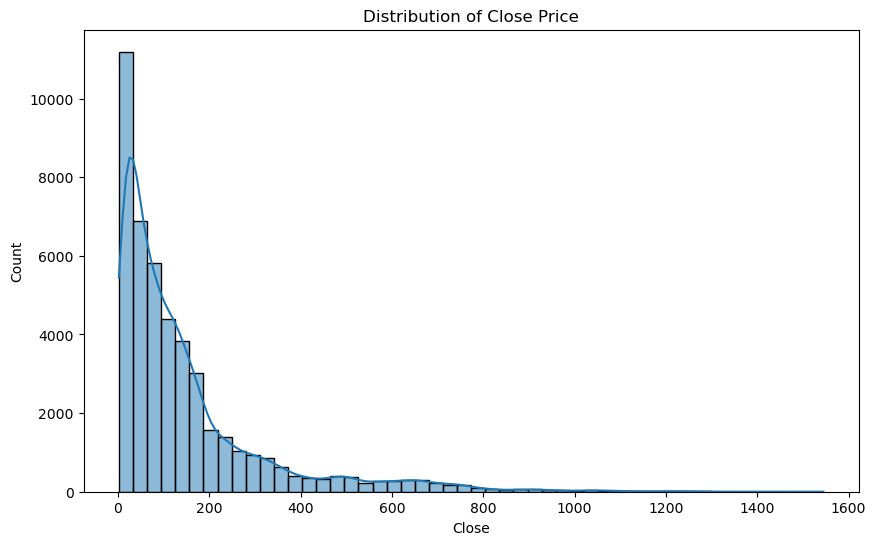

In [21]:

plt.figure(figsize=(10, 6))
sns.histplot(df['Close'], bins=50, kde=True)
plt.title('Distribution of Close Price')
plt.savefig('close_price_distribution.png')

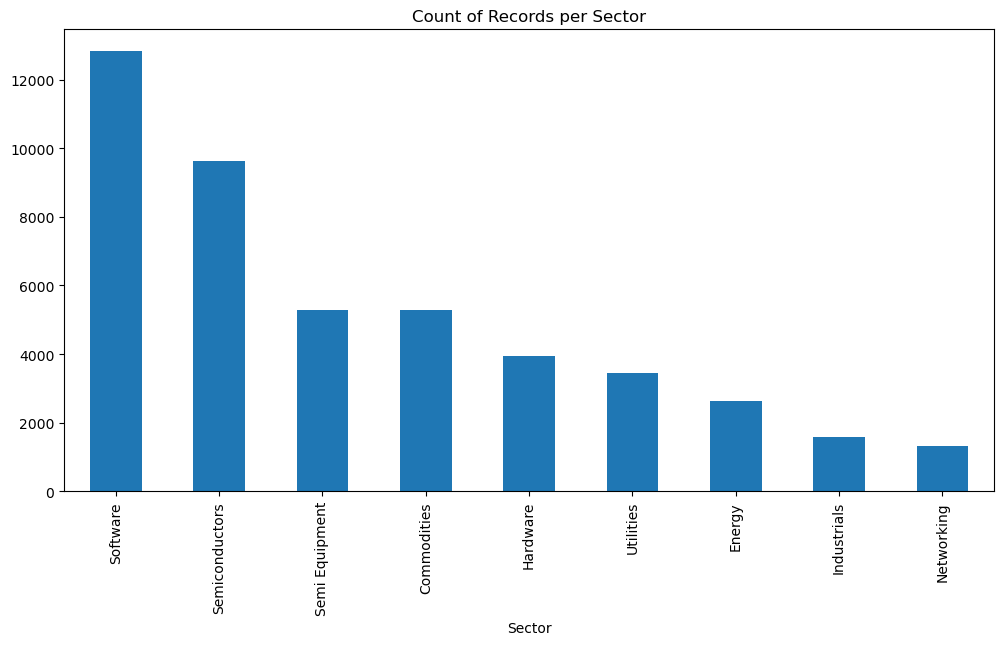

In [14]:
plt.figure(figsize=(12, 6))
df['Sector'].value_counts().plot(kind='bar')
plt.title('Count of Records per Sector')
plt.savefig('sector_distribution.png')

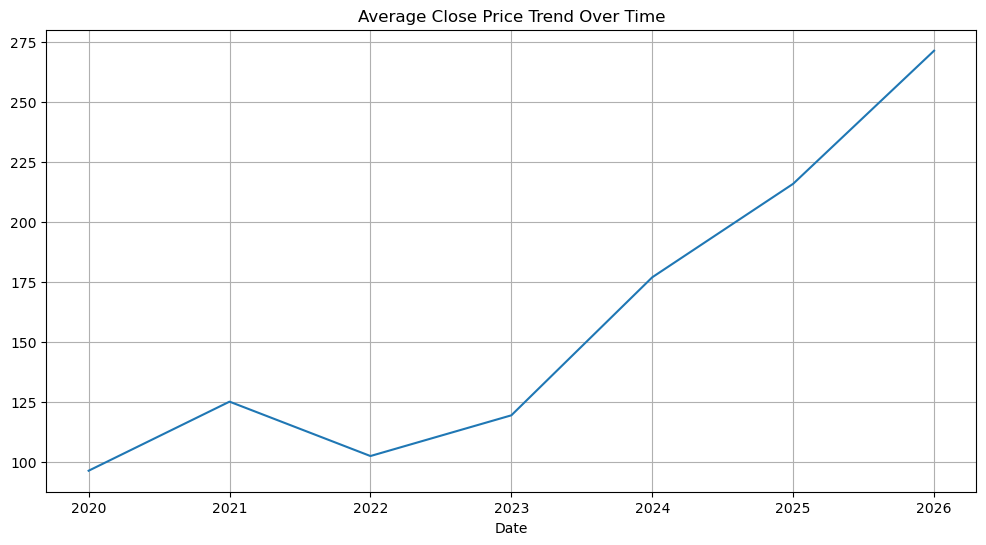

In [15]:

plt.figure(figsize=(12, 6))
df.groupby('Date')['Close'].mean().plot()
plt.title('Average Close Price Trend Over Time')
plt.grid(True)
plt.savefig('time_series_trend.png')

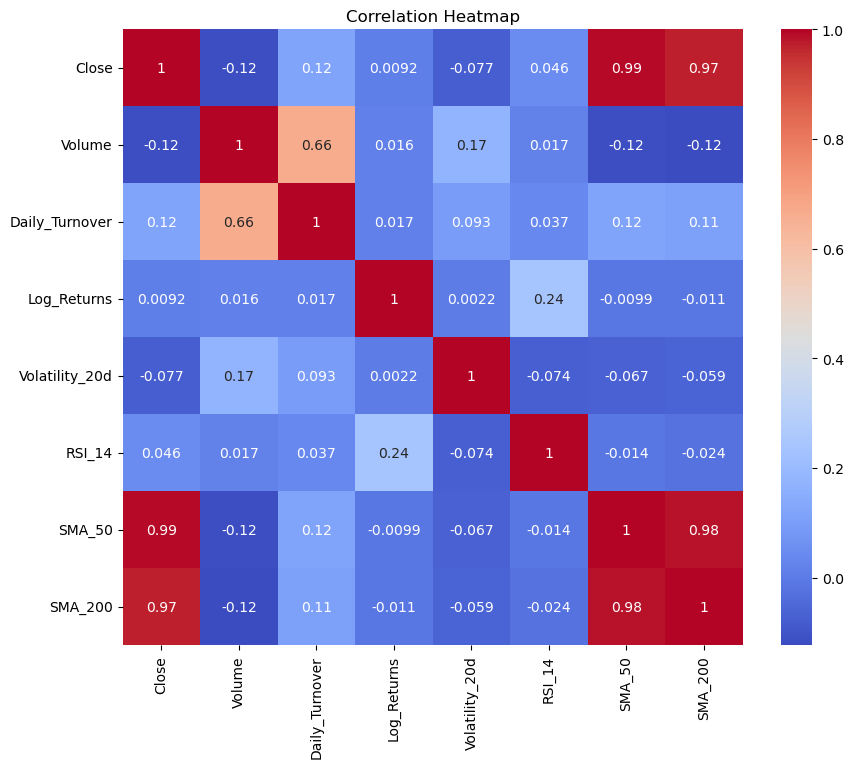

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

In [17]:
df=pd.read_csv(r"C:\Users\ALFIN FRANCY\Downloads\AI_Economy_Complete_Index (1).csv")
df

,Date,Ticker,Sector,Industry,Role,Close,Volume,Daily_Turnover,Log_Returns,Volatility_20d,RSI_14,SMA_50,SMA_200
0,2020-10-15,NVDA,Semiconductors,GPU Designer,AI Training Hardware,13.9267,267224000,3.721551e+09,-0.0089,0.3765,67.3471,12.7260,8.9561
1,2020-10-16,NVDA,Semiconductors,GPU Designer,AI Training Hardware,13.7687,242392000,3.337423e+09,-0.0114,0.3677,62.2981,12.7755,8.9951
2,2020-10-19,NVDA,Semiconductors,GPU Designer,AI Training Hardware,13.4559,298068000,4.010780e+09,-0.0230,0.3734,54.1464,12.8214,9.0330
3,2020-10-20,NVDA,Semiconductors,GPU Designer,AI Training Hardware,13.6032,229212000,3.118021e+09,0.0109,0.3737,51.8412,12.8709,9.0715
4,2020-10-21,NVDA,Semiconductors,GPU Designer,AI Training Hardware,13.4828,219596000,2.960777e+09,-0.0089,0.3374,48.5798,12.9243,9.1090
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45920,2026-01-09,SILJ,Commodities,Silver,Electronics Contacts,30.5600,7112200,2.173488e+08,0.0350,0.4597,67.1999,25.1734,18.3297
45921,2026-01-12,SILJ,Commodities,Silver,Electronics Contacts,32.2100,9744900,3.138832e+08,0.0526,0.4547,69.1927,25.3755,18.4302
45922,2026-01-13,SILJ,Commodities,Silver,Electronics Contacts,32.1200,10253400,3.293392e+08,-0.0028,0.4464,65.3782,25.5674,18.5289
45923,2026-01-14,SILJ,Commodities,Silver,Electronics Contacts,32.2800,10286200,3.320385e+08,0.0050,0.4426,65.3883,25.7693,18.6303


# Label Encoder

In [21]:
le = LabelEncoder()
for col in ['Ticker', 'Sector', 'Industry', 'Role']:
    df[col] = le.fit_transform(df[col])

# Data Preprocessing

In [22]:

X = df.drop(columns=['Close', 'Date'])
y = df['Close']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train Models

In [24]:

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42),
    "KNN Regression": KNeighborsRegressor(n_neighbors=5)
}

# Evaluate and Predict

In [25]:

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({"Algorithm": name, "R2_Score": r2, "MAE": mae})

# Training and Results

In [26]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} R2 Score: {r2_score(y_test, y_pred):.4f}")

Linear Regression R2 Score: 0.9908
Decision Tree R2 Score: 0.9969
Random Forest R2 Score: 0.9985
KNN Regression R2 Score: 0.8686


In [27]:
import joblib
joblib.dump(models['Random Forest'], 'model.pkl')

['model.pkl']